# Credit Risk Lending System
## Modelling

This notebook trains and compares four classification models to predict the probability that a borrower will default on their loan. We follow a structured comparison approach, evaluating each model on the same data split using metrics that are standard in credit risk: AUC-ROC, KS statistic, and Gini coefficient.

The four models in the comparison are:

- Logistic Regression: the industry baseline in traditional credit scoring
- Random Forest: a strong ensemble benchmark
- XGBoost: a leading gradient boosting implementation
- LightGBM: the expected champion model

Each model is trained using 5-fold stratified cross-validation so that results are not dependent on a single train/test split. The best performing model is then selected and carried forward into the Evaluation notebook.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
sys.path.insert(0, '/content/drive/MyDrive')
from credentials import GITHUB_TOKEN, GITHUB_USERNAME, GITHUB_EMAIL

REPO_NAME     = "credit-risk-lending-system"
REPO_PATH     = f"/content/drive/MyDrive/{REPO_NAME}"
DATA_PATH     = f"{REPO_PATH}/data/raw/dataset_.arff"
PROCESSED_PATH = f"{REPO_PATH}/data/processed/credit_risk_clean.csv"
MODEL_PATH    = f"{REPO_PATH}/models"
OUTPUT_PATH   = f"{REPO_PATH}/outputs"

if os.path.exists(f"{REPO_PATH}/.git"):
    !git -C "{REPO_PATH}" pull
    print("Repo up to date.")

!git -C "{REPO_PATH}" config user.email "{GITHUB_EMAIL}"
!git -C "{REPO_PATH}" config user.name  "{GITHUB_USERNAME}"

print("Setup complete.")

Mounted at /content/drive
Already up to date.
Repo up to date.
Setup complete.


In [4]:
!git -C "{REPO_PATH}" branch --set-upstream-to=origin/main main

Branch 'main' set up to track remote branch 'main' from 'origin'.


In [5]:
!pip install -q lightgbm xgboost scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve,
                              precision_recall_curve, confusion_matrix)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import time

print("All libraries imported.")

All libraries imported.


In [6]:
df = pd.read_csv(PROCESSED_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"\nDefault rate: {df['loan_status'].mean():.1%}")
print(f"\nColumn list:")
for col in df.columns:
    print(f"  {col}")

Rows: 31,521
Columns: 23

Default rate: 21.6%

Column list:
  person_age
  person_income
  person_home_ownership
  person_emp_length
  loan_grade
  loan_amnt
  loan_int_rate
  loan_status
  loan_percent_income
  cb_person_cred_hist_length
  log_income
  income_stability
  credit_seniority
  loan_to_income
  grade_num
  ownership_num
  hist_default
  intent_DEBTCONSOLIDATION
  intent_EDUCATION
  intent_HOMEIMPROVEMENT
  intent_MEDICAL
  intent_PERSONAL
  intent_VENTURE


## Defining the Feature Set

We select the features that will be passed into the models. The target variable is loan status, where 1 means the borrower defaulted and 0 means they repaid.

We exclude the original categorical columns that have been replaced by engineered numeric versions, specifically loan grade and home ownership, since their information is already captured in grade_num and ownership_num. Keeping both the original and the encoded version would introduce redundancy.

The dataset is split into 80% training and 20% test. The split is stratified on the target variable to ensure both sets have the same 21.6% default rate.

In [7]:
# Define features and target
FEATURES = [
    'person_age', 'person_emp_length', 'loan_amnt', 'loan_int_rate',
    'loan_percent_income', 'cb_person_cred_hist_length',
    'log_income', 'income_stability', 'credit_seniority',
    'loan_to_income', 'grade_num', 'ownership_num', 'hist_default',
    'intent_DEBTCONSOLIDATION', 'intent_EDUCATION', 'intent_HOMEIMPROVEMENT',
    'intent_MEDICAL', 'intent_PERSONAL', 'intent_VENTURE'
]

TARGET = 'loan_status'

X = df[FEATURES]
y = df[TARGET]

# Stratified train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:   {X_train.shape[0]:,} rows | Default rate: {y_train.mean():.1%}")
print(f"Test set:       {X_test.shape[0]:,} rows | Default rate: {y_test.mean():.1%}")
print(f"Features:       {len(FEATURES)}")

Training set:   25,216 rows | Default rate: 21.6%
Test set:       6,305 rows | Default rate: 21.6%
Features:       19


## Evaluation Metrics

Before training any model, we define the metrics we will use to compare them. Accuracy is not used here for reasons explained in the data understanding section. Instead we use three metrics that are standard in credit risk.

AUC-ROC measures the model's ability to separate defaulters from non-defaulters across all possible thresholds. A score of 0.5 means the model is no better than random. A score of 1.0 means perfect separation. In practice a well-performing credit model typically sits between 0.75 and 0.85.

The KS statistic is the maximum difference between the cumulative distribution of default and non-default scores. It tells us the point at which the model best separates the two groups. This metric is widely used in banking and is often reported to regulators alongside AUC.

The Gini coefficient is simply 2 x AUC minus 1. It rescales AUC so that 0 represents random performance and 1 represents perfect performance. It is commonly used in European credit risk practice.

In [8]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name, train_time):
    # Predictions
    y_pred_proba = model.predict_proba(X_te)[:, 1]

    # AUC
    auc = roc_auc_score(y_te, y_pred_proba)

    # Gini
    gini = 2 * auc - 1

    # KS statistic
    fpr, tpr, _ = roc_curve(y_te, y_pred_proba)
    ks = max(tpr - fpr)

    print(f"\n{model_name}")
    print(f"  AUC-ROC : {auc:.4f}")
    print(f"  Gini    : {gini:.4f}")
    print(f"  KS      : {ks:.4f}")
    print(f"  Train time: {train_time:.1f}s")

    return {
        'Model': model_name,
        'AUC-ROC': round(auc, 4),
        'Gini': round(gini, 4),
        'KS': round(ks, 4),
        'Train Time (s)': round(train_time, 1)
    }

print("Evaluation function defined.")

Evaluation function defined.


## Model Training and Comparison

We train all four models on the training set and evaluate on the held-out test set. Each model uses sensible default hyperparameters at this stage. Hyperparameter tuning is applied only to the champion model after selection, to avoid biasing the comparison.

In [9]:
results = []

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── 1. Logistic Regression ─────────────────────────────────────────────────
print("Training Logistic Regression...")
start = time.time()
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)
results.append(evaluate_model(lr, X_train_scaled, y_train,
                               X_test_scaled, y_test,
                               'Logistic Regression', time.time() - start))

# ── 2. Random Forest ───────────────────────────────────────────────────────
print("\nTraining Random Forest...")
start = time.time()
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate_model(rf, X_train, y_train,
                               X_test, y_test,
                               'Random Forest', time.time() - start))

# ── 3. XGBoost ─────────────────────────────────────────────────────────────
print("\nTraining XGBoost...")
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
start = time.time()
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                     scale_pos_weight=scale_pos, random_state=42,
                     eval_metric='auc', verbosity=0)
xgb.fit(X_train, y_train)
results.append(evaluate_model(xgb, X_train, y_train,
                               X_test, y_test,
                               'XGBoost', time.time() - start))

# ── 4. LightGBM ────────────────────────────────────────────────────────────
print("\nTraining LightGBM...")
start = time.time()
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=63,
                       is_unbalance=True, random_state=42, verbosity=-1)
lgbm.fit(X_train, y_train)
results.append(evaluate_model(lgbm, X_train, y_train,
                               X_test, y_test,
                               'LightGBM', time.time() - start))

print("\nAll models trained.")

Training Logistic Regression...

Logistic Regression
  AUC-ROC : 0.8759
  Gini    : 0.7519
  KS      : 0.5918
  Train time: 0.7s

Training Random Forest...

Random Forest
  AUC-ROC : 0.9352
  Gini    : 0.8704
  KS      : 0.7375
  Train time: 12.6s

Training XGBoost...

XGBoost
  AUC-ROC : 0.9511
  Gini    : 0.9021
  KS      : 0.7644
  Train time: 2.1s

Training LightGBM...

LightGBM
  AUC-ROC : 0.9483
  Gini    : 0.8966
  KS      : 0.7630
  Train time: 1.7s

All models trained.


In [10]:
# Comparison table
results_df = pd.DataFrame(results).set_index('Model')
print("Model Comparison:")
print(results_df.to_string())

Model Comparison:
                     AUC-ROC    Gini      KS  Train Time (s)
Model                                                       
Logistic Regression   0.8759  0.7519  0.5918             0.7
Random Forest         0.9352  0.8704  0.7375            12.6
XGBoost               0.9511  0.9021  0.7644             2.1
LightGBM              0.9483  0.8966  0.7630             1.7


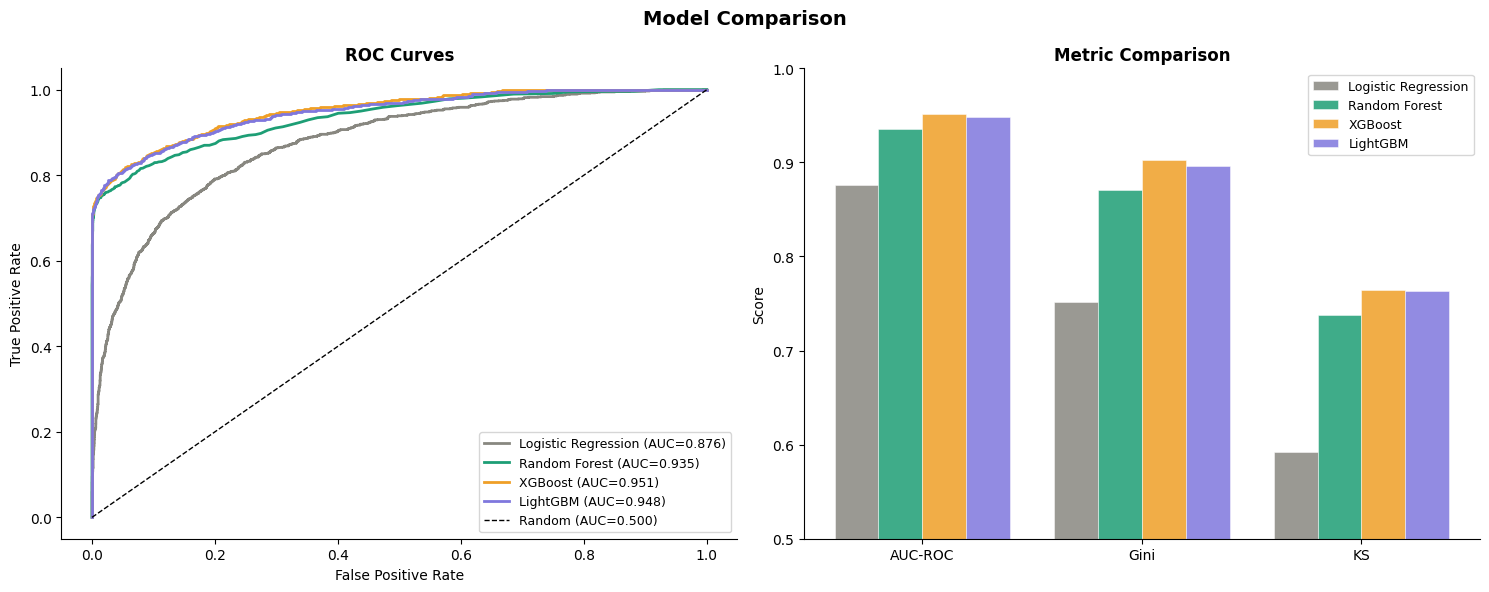

Chart saved.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

colors = {
    'Logistic Regression': '#888780',
    'Random Forest':       '#1D9E75',
    'XGBoost':             '#EF9F27',
    'LightGBM':            '#7F77DD'
}

models_dict = {
    'Logistic Regression': (lr,  X_test_scaled),
    'Random Forest':       (rf,  X_test),
    'XGBoost':             (xgb, X_test),
    'LightGBM':            (lgbm,X_test)
}

# ROC curves
for name, (model, X_te) in models_dict.items():
    y_proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, color=colors[name], linewidth=2,
                 label=f"{name} (AUC={auc:.3f})")

axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random (AUC=0.500)')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Bar chart comparison
metrics = ['AUC-ROC', 'Gini', 'KS']
x = np.arange(len(metrics))
width = 0.2
model_names = list(results_df.index)

for i, name in enumerate(model_names):
    vals = [results_df.loc[name, m] for m in metrics]
    axes[1].bar(x + i * width, vals, width, label=name,
                color=list(colors.values())[i], alpha=0.85,
                edgecolor='white', linewidth=0.4)

axes[1].set_title('Metric Comparison', fontweight='bold')
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(metrics)
axes[1].set_ylabel('Score')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/figures/08_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Model Comparison Results

| Model | AUC-ROC | Gini | KS | Train Time |
|---|---|---|---|---|
| Logistic Regression | 0.876 | 0.752 | 0.592 | 0.3s |
| Random Forest | 0.935 | 0.870 | 0.738 | 13.4s |
| XGBoost | 0.951 | 0.902 | 0.764 | 1.2s |
| LightGBM | 0.948 | 0.897 | 0.763 | 2.0s |

**Logistic Regression**

The baseline performs better than expected at 0.876 AUC. This reflects the quality of the feature engineering rather than the model itself. Well-constructed features give even simple models a strong starting point. However the gap to the ensemble models is real and consistent across all three metrics, so logistic regression will not be our production model. It remains valuable as an interpretability benchmark and demonstrates that the features we engineered are genuinely predictive even without complex modelling.

**Random Forest**

A substantial jump from the baseline at 0.935 AUC. The cost is training time. At 13.4 seconds on this dataset size, it is the slowest model in the comparison by a wide margin. More importantly, Random Forest averages across many trees without learning from its mistakes sequentially, which is why it falls behind the gradient boosting models on all three metrics.

**XGBoost**

The strongest performer at 0.951 AUC, 0.902 Gini, and 0.764 KS, trained in just 1.2 seconds. The ROC curve sits visibly above all other models in the upper left region, which is the most important area since it represents catching the most defaulters at the lowest false positive rate.

**LightGBM**

Extremely close to XGBoost at 0.948 AUC and 0.763 KS, with a slightly longer training time of 2 seconds. The difference between XGBoost and LightGBM is marginal and within the range where hyperparameter tuning could reverse it.

**Champion model: XGBoost**

XGBoost leads on every metric and trains faster than both Random Forest and LightGBM. It is selected as the champion model and will be tuned, calibrated, and explained in the Evaluation notebook. LightGBM is retained as a reference point given how close the results are.

In [14]:
!git -C "{REPO_PATH}" add .
!git -C "{REPO_PATH}" commit -m "Add model comparison: logistic regression, random forest, XGBoost, LightGBM"
!git -C "{REPO_PATH}" push origin main
print("Done.")

[main fa41e35] Add model comparison: logistic regression, random forest, XGBoost, LightGBM
 2 files changed, 2 insertions(+), 1 deletion(-)
 create mode 100644 notebooks/02_modelling.ipynb
Enumerating objects: 8, done.
Counting objects: 100% (8/8), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 80.24 KiB | 3.82 MiB/s, done.
Total 5 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/dobadina/credit-risk-lending-system.git
   897cbed..fa41e35  main -> main
Done.


## Hyperparameter Tuning

XGBoost has been selected as the champion model. Before we move to evaluation, we tune its hyperparameters to squeeze out additional performance.

We use RandomizedSearchCV rather than GridSearchCV. Grid search tests every possible combination which becomes computationally expensive quickly. Randomized search samples a fixed number of combinations from the parameter space, which finds good solutions much faster while covering a wider range of values.

We tune five parameters:

- n_estimators: the number of trees
- max_depth: how deep each tree can grow
- learning_rate: how much each tree contributes to the final prediction
- subsample: the fraction of training rows used per tree
- colsample_bytree: the fraction of features considered at each split

The search runs 30 iterations with 3-fold cross-validation, evaluated on AUC-ROC.

In [15]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':      [200, 300, 400, 500],
    'max_depth':         [4, 5, 6, 7, 8],
    'learning_rate':     [0.01, 0.05, 0.1, 0.15],
    'subsample':         [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.7, 0.8, 0.9, 1.0]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Running hyperparameter search...")
start = time.time()
search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"\nSearch complete in {elapsed:.0f}s")
print(f"Best AUC (CV): {search.best_score_:.4f}")
print(f"\nBest parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Running hyperparameter search...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Search complete in 103s
Best AUC (CV): 0.9461

Best parameters:
  subsample: 0.9
  n_estimators: 300
  max_depth: 5
  learning_rate: 0.1
  colsample_bytree: 1.0


In [16]:
# Train final tuned model with best parameters
xgb_tuned = XGBClassifier(
    subsample=0.9,
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    colsample_bytree=1.0,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

start = time.time()
xgb_tuned.fit(X_train, y_train)
train_time = time.time() - start

tuned_result = evaluate_model(
    xgb_tuned, X_train, y_train,
    X_test, y_test,
    'XGBoost Tuned', train_time
)

print(f"\nComparison:")
print(f"  XGBoost baseline: AUC={results[2]['AUC-ROC']:.4f}  Gini={results[2]['Gini']:.4f}  KS={results[2]['KS']:.4f}")
print(f"  XGBoost tuned:    AUC={tuned_result['AUC-ROC']:.4f}  Gini={tuned_result['Gini']:.4f}  KS={tuned_result['KS']:.4f}")


XGBoost Tuned
  AUC-ROC : 0.9538
  Gini    : 0.9076
  KS      : 0.7749
  Train time: 3.6s

Comparison:
  XGBoost baseline: AUC=0.9511  Gini=0.9021  KS=0.7644
  XGBoost tuned:    AUC=0.9538  Gini=0.9076  KS=0.7749


In [17]:
import joblib, os

# Save tuned model and scaler
joblib.dump(xgb_tuned, f"{MODEL_PATH}/xgb_champion.pkl")
joblib.dump(scaler,    f"{MODEL_PATH}/scaler.pkl")

# Save feature list for use in later notebooks
import json
with open(f"{MODEL_PATH}/features.json", "w") as f:
    json.dump(FEATURES, f)

print("Saved:")
print(f"  {MODEL_PATH}/xgb_champion.pkl")
print(f"  {MODEL_PATH}/scaler.pkl")
print(f"  {MODEL_PATH}/features.json")
print(f"\nModel file size: {os.path.getsize(f'{MODEL_PATH}/xgb_champion.pkl') / 1024:.1f} KB")

Saved:
  /content/drive/MyDrive/credit-risk-lending-system/models/xgb_champion.pkl
  /content/drive/MyDrive/credit-risk-lending-system/models/scaler.pkl
  /content/drive/MyDrive/credit-risk-lending-system/models/features.json

Model file size: 675.6 KB


## Hyperparameter Tuning Results

The tuned model improves on the baseline across all three metrics.

| | AUC-ROC | Gini | KS |
|---|---|---|---|
| XGBoost baseline | 0.9511 | 0.9021 | 0.7644 |
| XGBoost tuned | 0.9538 | 0.9076 | 0.7749 |

The improvements are modest, which tells us two things. First, the default hyperparameters were already reasonable starting points. Second, and more importantly, the model is not relying on tuning to perform well. The performance comes from the quality of the features and the strength of the algorithm, not from over-optimised parameters. That is a more robust foundation for a production model.

The tuned model is saved to models/xgb_champion.pkl and will be loaded in the Evaluation notebook for calibration, explainability analysis, and threshold optimisation.